## Fit to HAT-P-70b

This notebook demonstrates how to generate a transit light curve from a set of parameters, using a pre-defined function based on analytical formulae provided in the book by Haswell (Exoplanet Transits).

We assume quadratic limb-darkening coefficients.

For TESS, limb-darkening coefficients for a grid of Teffs and log g are provided by Claret (2017) - interpolate that table for the Teff, gravity and metallicity of the host star.

In [1]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt

### Definition of model light curve with limb darkening

The following cell defines the model - requires an array of x-axis values in days; parameters to define the planet and orbit; and quadratic limb-darkening coefficients.

In [2]:
def model_wLD(jd_times, OrbitPeriod, T_centre, pp, aR, b, mu1, mu2):

    """
    Returns flux ratio during transit, sampled at the timepoints given

    jd_times: array of timepoints in days [JD or HJD/BJD]
    OrbitPeriod: period of orbit in days
    T_centre: time of central transit in days
    pp: Rp/R*, ratio of planet/star radii (dimensionless)
    aR: a/R*, ratio of semi-major axis to star radius (dimensionless)
    b: impact parameter (dimensionless)
    mu1,mu2: limb-darkening coefficients (dimensionless)

    Returns: array of flux ratios at jd_times

    """

    import numpy as np

    td = jd_times - T_centre
    tpoints=np.size(jd_times)

    inc=np.arccos(b/aR)
    om=2.0*np.pi/OrbitPeriod

    # LD coefficients
    c1=0.0
    c2=mu1 + 2.0*mu2
    c3=0.0
    c4=-mu2
    c0=1.0-c1-c2-c3-c4

    # Choice of parameterized variable for time (ksi):

    ksi = aR * np.sqrt(np.sin(om*td)**2+np.cos(inc)**2*np.cos(om*td)**2)
    cos_a_1 = ((ksi**2+pp**2-1.)/(2*ksi*pp))
    cos_a_2 = (ksi**2+1.-pp**2)/(2*ksi)

    #Haswell pp.107
    a_1=np.zeros_like(cos_a_1)
    a_2=np.zeros_like(cos_a_2)

    c_sum=(6.0-2.0*mu1 - mu2)/24.0
    a=np.zeros_like(ksi)
    Ir=np.zeros_like(ksi)
    Ir_star=np.zeros_like(ksi)
    a=(ksi - pp)**2

    Ir1=np.zeros_like(ksi)
    Ir2=np.zeros_like(ksi)
    Ir3=np.zeros_like(ksi)

    deltaF=np.zeros_like(ksi)
    A_part=np.zeros_like(ksi)

    for i in range(tpoints):
        if (np.abs(cos_a_1[i])>1 or np.abs(cos_a_2[i]) > 1): #outside of ingress/egress

            if ksi[i] > 1: #before/ after transit
                deltaF[i]=0

            elif (ksi[i] < 1): #full transit

                Ir1[i]=(c0+c4)*((ksi[i]+pp)**2 - (ksi[i]-pp)**2)
                Ir2[i]=c4*(((ksi[i]+pp)**2)/2 - ((ksi[i]-pp)**2)/4)
                Ir3[i]=(2/3)*c2*(np.cos(np.arcsin(ksi[i]+pp))**3 - np.cos(np.arcsin(ksi[i]-pp))**3)
                Ir[i]=Ir1[i] - Ir2[i] - Ir3[i]

                r1=(ksi[i]+pp)**2
                r2=(ksi[i]-pp)**2
                Ir[i]=r1-r2 \
                      - mu1*((-1+r1+(2/3)*((1-r1)**(3/2))) - (-1+r2+(2/3)*((1-r2)**(3/2)))) \
                      - mu2*((-(1/2)*((-r1+1)**2)+(4/3)*((-r1+1)**(3/2))+r1-1) \
                      - (-(1/2)*((-r2+1)**2)+(4/3)*((-r2+1)**(3/2))+r2-1))

                deltaF[i]=(pp/(16*c_sum*ksi[i]))*Ir[i] # <---- Drop in flux


        elif (np.abs(cos_a_1[i]) < 1 and np.abs(cos_a_2[i]) < 1): #ingress/egress
            a_1[i] = np.arccos(cos_a_1[i])
            a_2[i] = np.arccos(cos_a_2[i])
            cos1=np.cos(np.arcsin(ksi[i] - pp))
            cos3=cos1**3.0

            #found number of possible solutions for I[i] from integral
            #Ir[i]=(c0+c4)*(1-a[i]) - (c4/2)*(1-a[i]**2) + (2/3)*c2*cos1**3
            #Ir[i]=c0 - (c4/2)*(1.0+(a[i])**2) - (c0-c4)*a[i] - (2/3)*c2*cos1**3
            #Ir[i]=c0*(1.0-a[i]) + c4*((1.0-(a[i])**2)/2 - a[i]) + (2/3)*c0*cos1**3
            #Ir[i]=c0 - (c4/2)*(1+a[i]**2) + a[i]*(c4-c0) - (2/3)*cos1**3

            Ir[i]=c0*(1-a[i]) + c4*(1/2 - a[i] + (a[i]**2)/2) + (2/3)*c2*cos3

            Ir_star[i]=Ir[i]/(1-a[i])
            f2=pp**2*np.arccos((ksi[i] - 1.0)/pp) - (ksi[i] - 1.0)*(np.sqrt(pp**2 - (ksi[i] - 1.0)**2))
            deltaF[i]=(Ir_star[i]/(4*c_sum))*f2*(1.0/np.pi)

#         else:
#             print("not sure what's going on here")

    fluxratio=1.0-deltaF

    return fluxratio

### Sample call to generate a transit light curve

See below for a declaration of the parameters, and then a call to the function to obtain the light curve.

In [3]:
# set a range of x-axis values, between limits, and with time sampling
x1 = -6.0/24.0
x2 = +6.0/24.0
dx = 5.0/60.0/24.0

x_days = np.arange(x1,x2,dx)

# Orbital period in days
p_period = 2.744

# Transit centre in days
t_centre = 0.00

# Planet-to-star radius ratio, Rp/R*
rprs1 = 0.09

# Semi-major-axis-to-star-radius ratio, a/R*
arstar = 5.45

# impact parameter, b
bparam = -0.63

# limb-darkening coeffs
ld1 = 0.1870
ld2 = 0.2672


In [4]:
#call the function
y_flux1 = model_wLD(x_days,p_period,t_centre,rprs1,arstar,bparam,ld1,ld2)
#y_flux2 = model_wLD(x_days,p_period,t_centre,rprs2,arstar,bparam,ld1,ld2)

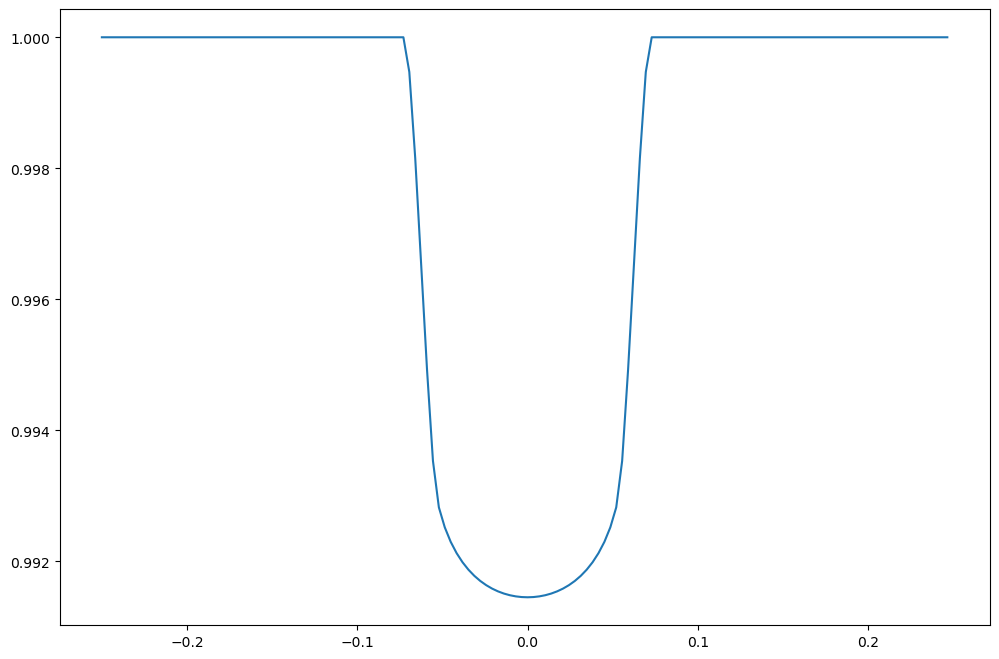

In [5]:
# Plot it up
plt.figure(figsize=(12,8))
plt.plot(x_days,y_flux1)
#plt.plot(x_days,y_flux2)

If you wish, you can go back and change parameters; if you want to see the effect of changes, try creating y_flux2, y_flux3 (with different model parameters), and then plotting together on one plot.

## Fitting to some data

We'll read in a data file from TESS (so you may have to navigate to the file from this notebook), that we saved as a csv with x in days, y in relative flux, and y errors.

We'll mask it, so that we only use data within a few hours of the transit.

In [6]:
data = np.loadtxt('./hat-p-70b.csv',skiprows=1,delimiter=',')

x, y, y_err = np.hsplit(data,3)
x = x.flatten()
y = y.flatten()
y_err = y_err.flatten()

x_lower = -0.25 # in days
x_upper = +0.25 # in days

mask = (x > x_lower) & (x < x_upper)

x_mask = x[mask]
y_mask = y[mask]
y_mask_err = y_err[mask]

Plot up all the data, and then the masked section

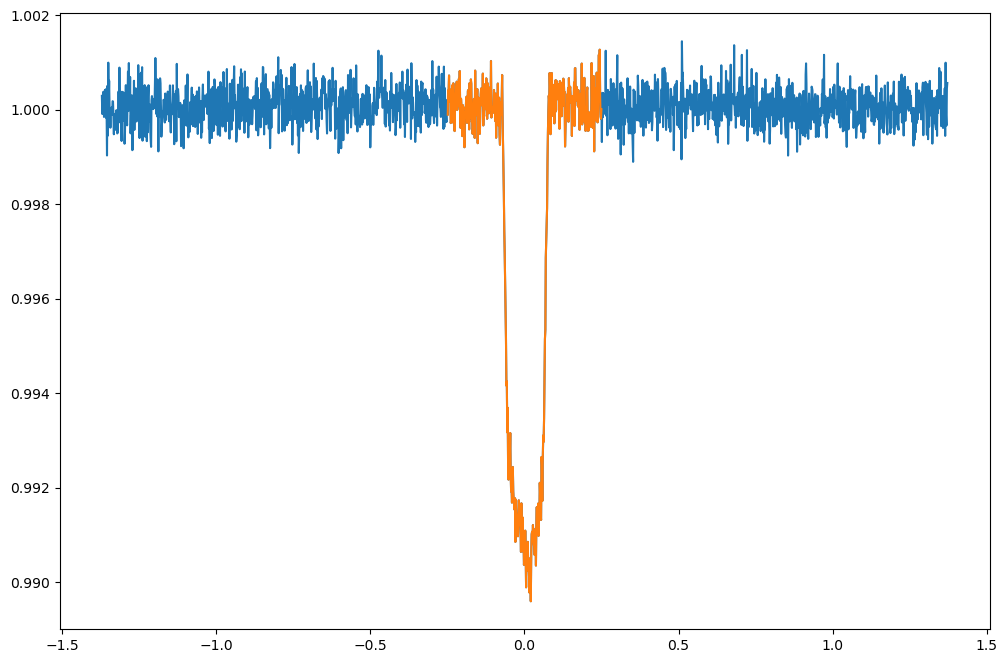

In [7]:
plt.figure(figsize=(12,8))

plt.plot(x,y)

plt.plot(x_mask,y_mask)

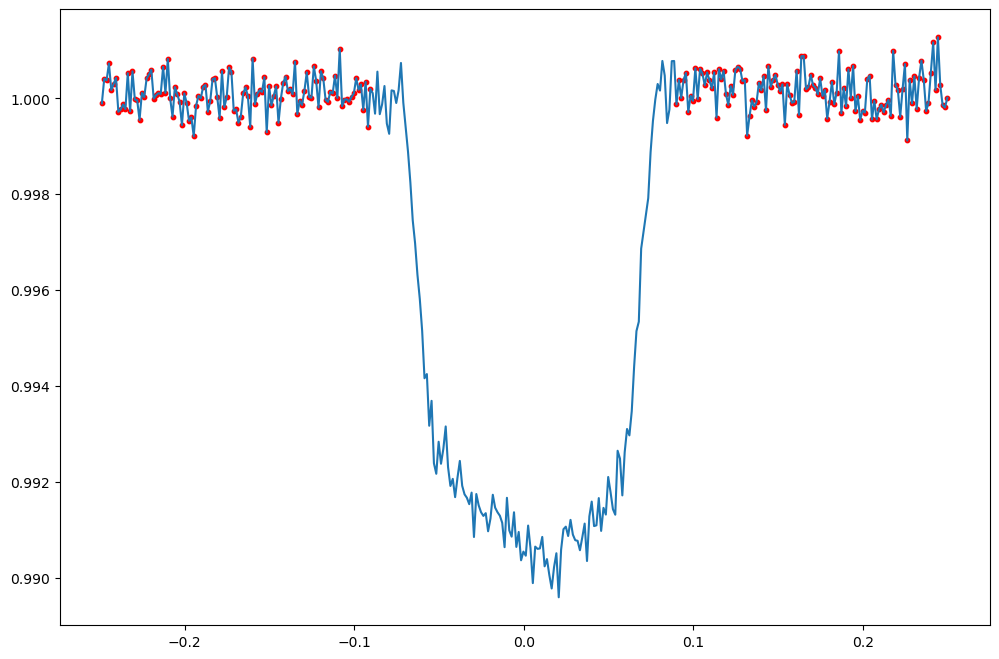

In [8]:
# Plot only the masked section

plt.figure(figsize=(12,8))
plt.plot(x_mask,y_mask)

# Define the out-of-transit limits too, and mask to select those - plot in a different colour

x_ingress = -0.09
x_egress = +0.09

# Out of transit mask is either pre-ingress OR post-egress
oot_mask = (x_mask < x_ingress) | (x_mask > x_egress)

x_oot = x_mask[oot_mask]
y_oot = y_mask[oot_mask]
yerr_oot = y_mask_err[oot_mask]

plt.scatter(x_oot,y_oot,c='r',s=10.0)


### Renormalize in y axis using out of transit data

We might wish to renormalize the data to the out-of-transit (oot) level. So we define a mask for the out of transit, and then find the mean of this section. You could also do a linear or polynomial fit to be more exact, where the data justify it, as they may do for Kelt-9b. Both of these are demonstrated below.

In [9]:
print(np.mean(y_oot))

1.0001299714372294


In [10]:
from numpy.polynomial import polynomial as P
from numpy import polyval

x = x_oot
y = y_oot
yerr = yerr_oot
wts = 1/yerr**2

order = 1

coeffs = P.polyfit(x,y,order,full=False)
print(coeffs)

#yfit2 = coeffs[0] + coeffs[1]*x + coeffs[2]*x**2

[1.00012980e+00 1.96048127e-04]


In [11]:
# Can also be done direct with polyval (x_array, coeffs)

yfit = P.polyval(x_mask,coeffs)

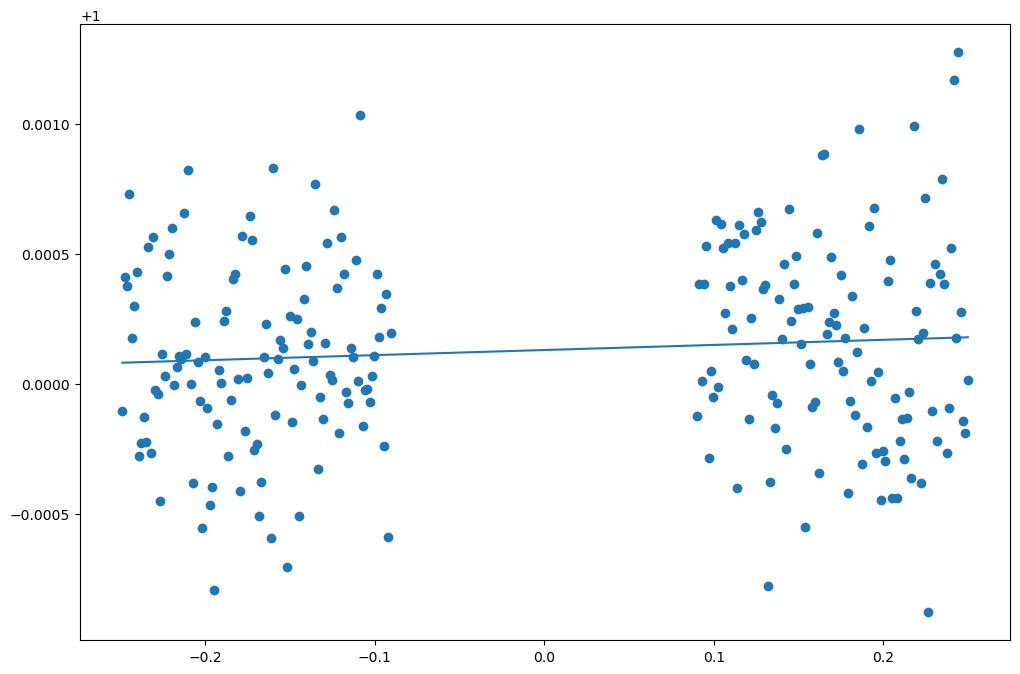

In [12]:
# Plot only the OOT section with the fit

plt.figure(figsize=(12,8))
plt.scatter(x_oot,y_oot)

#plt.plot(x_oot,yfit2)
plt.plot(x_mask,yfit)


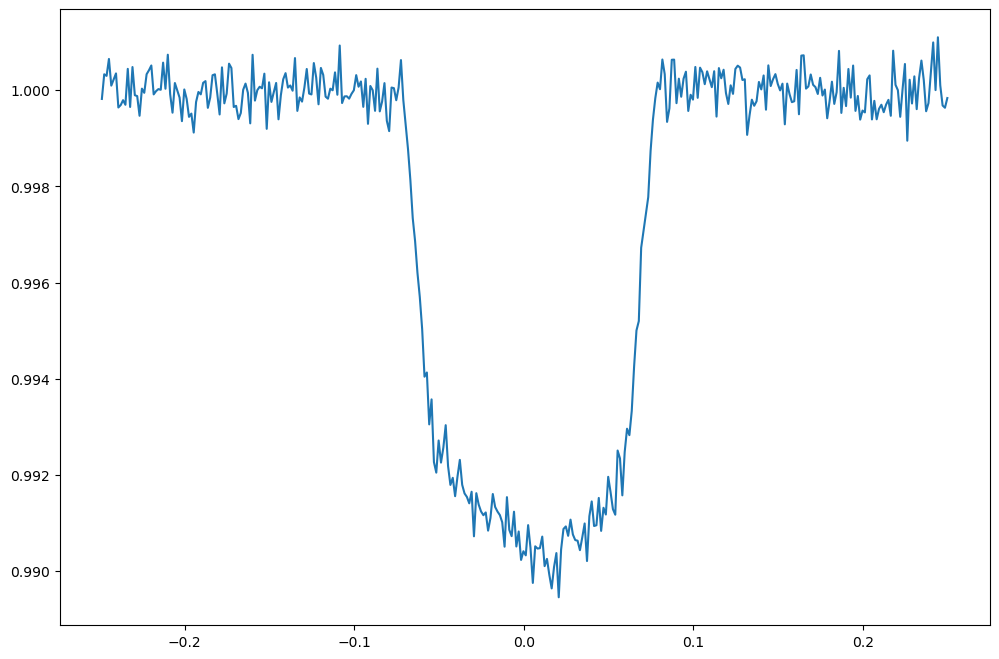

In [13]:
# divide by the mean out-of-transit values
y_renorm = y_mask/np.mean(y_oot)
y_renorm_err = y_mask_err/np.mean(y_oot)

# OR divide by the fit
y_renorm = y_mask/yfit
y_renorm_err = y_mask_err/yfit

plt.figure(figsize=(12,8))
plt.plot(x_mask,y_renorm)

### Fitting the model

The next cell actually fits the model to the data, using the scipy.optimize.curve tool, and passing it the function, the data values, and the initial parameter set and bounds.

Note:

1. We should not fit all parameters, as we prefer first to check against the published values.

2. To constrain the fit, set the bounds within which the fit is permitted to search.

3. Hence, to FIX a given parameter, set the bounds to be very tight, just above and below the published parameter (and well within its published error bar, for example).

4. For parameters that you wish to fit, widen the bounds accordingly, to let the optimizer search the parameter space.

Always leave the orbital period and the limb darkening parameters as "fixed" values (tight bounds).

I would suggest you try first generating a curve using only published parameters and fitting the central transit time only, and see how well the curve matches the data.

If that's not a good match, allow the transit depth to be fitted also (after all, the TESS data may well be an improvement on the published parameters, but our limb-darkening parameters must also be reasonable).

And then finally, allow the a/R* and b parameters to be fit also.

You can check the quality of the fit at each stage, using chi-squared as your guide. Note that if there is significant deviation due to gravity darkening, then chi-squared should still be unreasonably large (we can check this with standard methods), even after allowing maximum freedom in the fitted parameters.

In [ ]:
#FITTING PARAMETERS

popt, pcov = opt.curve_fit(
    f=model_wLD,
    xdata=x_mask,
    ydata=y_renorm,
    sigma=y_renorm_err,
    absolute_sigma=True,
    #
    # Set parameters to published values:
    #
    p0=[
        2.744,        #  FIX: OrbitPeriod: period of orbit in days
        0,            #  T_centre: time of central transit in days
        0.09,        #  pp: Rp/R*, ratio of planet/star radii (dimensionless) (FIX or FIT)
        5.45,         #  aR: a/R*, ratio of semi-major axis to star radius (dimensionless) (FIX to published)
        -0.63,        #  b: impact parameter (dimensionless) (FIX to published)
        0.1870,       #  mu1,mu2: quadratic limb-darkening coefficients (dimensionless)
        0.2672        #  from Claret (2017) - FIX these to interpolated values
        ],
    bounds = (
        [2.7439,-0.5,0.01,2.00,-0.99,0.18699,0.26719],
        [2.7441,+0.5,0.50,10.00,-0.01,0.18701,0.26721],
    ),
    maxfev=100_000
)

print("Fitted (or fixed) parameters: \n",
      "Period:         ", popt[0], "\n",
      "Transit centre: ", popt[1], "\n",
      "Rp/R*:          ", popt[2], "\n",
      "a/R*:           ", popt[3], "\n",
      "b:              ", popt[4], "\n",
      "mu1:            ", popt[5], "\n",
      "mu2:            ", popt[6], "\n",
     )



Fitted (or fixed) parameters: 
 Period:          2.7439002032361057 
 Transit centre:  0.0034842346580182906 
 Rp/R*:           0.09378099684869402 
 a/R*:            5.242405509342813 
 b:               -0.6179137518434664 
 mu1:             0.18700999999999998 
 mu2:             0.2672099999986138 



In [ ]:
#FIX PARAMETERS
popt, pcov = opt.curve_fit(
    f=model_wLD,
    xdata=x_mask,
    ydata=y_renorm,
    sigma=y_renorm_err,
    absolute_sigma=True,
    #
    # Set parameters to published values:
    #
    p0=[
        2.744,        #  FIX: OrbitPeriod: period of orbit in days
        0,            #  T_centre: time of central transit in days
        0.09,        #  pp: Rp/R*, ratio of planet/star radii (dimensionless) (FIX or FIT)
        5.45,         #  aR: a/R*, ratio of semi-major axis to star radius (dimensionless) (FIX to published)
        -0.63,        #  b: impact parameter (dimensionless) (FIX to published)
        0.1870,       #  mu1,mu2: quadratic limb-darkening coefficients (dimensionless)
        0.2672        #  from Claret (2017) - FIX these to interpolated values
        ],
    bounds = (
        [2.7439,-0.5,0.08,5.44,-0.64,0.18699,0.26719],
        [2.7441,+0.5,0.10,5.46,-0.62,0.18701,0.26721],
    ),
    maxfev=100_000
)

print("Fitted (or fixed) parameters: \n",
      "Period:         ", popt[0], "\n",
      "Transit centre: ", popt[1], "\n",
      "Rp/R*:          ", popt[2], "\n",
      "a/R*:           ", popt[3], "\n",
      "b:              ", popt[4], "\n",
      "mu1:            ", popt[5], "\n",
      "mu2:            ", popt[6], "\n",
     )

Fitted (or fixed) parameters: 
 Period:          2.7440999999999995 
 Transit centre:  0.0038387077354411353 
 Rp/R*:           0.09472845060357082 
 a/R*:            5.440000000000001 
 b:               -0.6200000000000002 
 mu1:             0.18699000000000002 
 mu2:             0.26719000000000004 



### Plot up the data and the fit

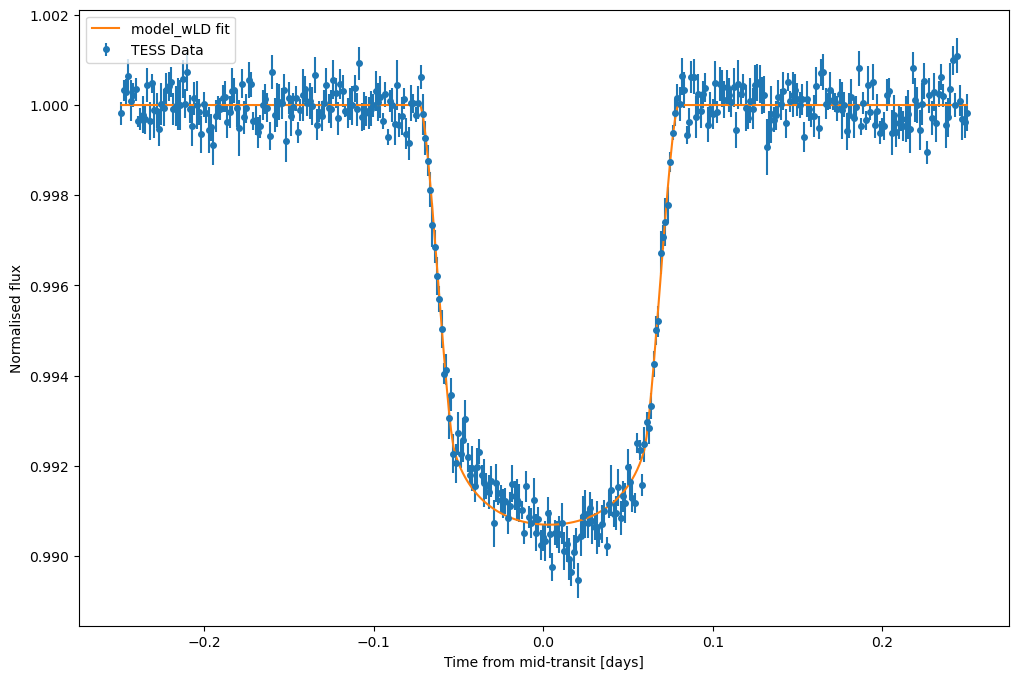

In [35]:
plt.figure(figsize=(12,8))
plt.errorbar(
    x_mask,
    y_renorm,
    y_renorm_err,
    fmt='o',
    ms=4,
    label='TESS Data'
)

y_fit = model_wLD(x_mask,*popt)

plt.plot(
    x_mask,
    y_fit,
    label='model_wLD fit'

)

plt.xlabel('Time from mid-transit [days]')
plt.ylabel('Normalised flux')

plt.legend()
plt.show()





### Plot the residuals

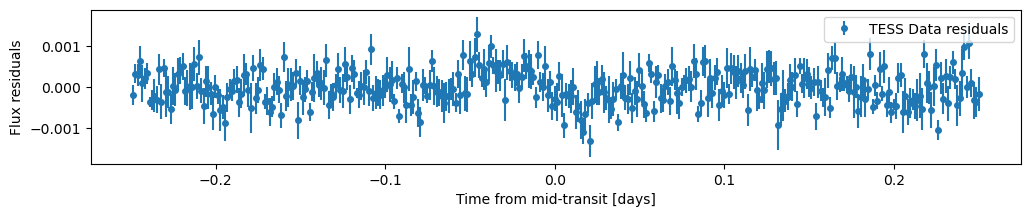

In [36]:
y_residuals = y_renorm - y_fit

plt.figure(figsize=(12,2))
plt.errorbar(
    x_mask,
    y_residuals,
    y_mask_err,
    fmt='o',
    ms=4,
    label='TESS Data residuals'
)
#plt.scatter(
#    x_oot,
#    y_residuals[oot_mask],
#    c='red',
#    s=20.0
#    )

plt.xlabel('Time from mid-transit [days]')
plt.ylabel('Flux residuals')

plt.legend()
plt.show()



### Calculate some statistics and chi-squared

In [17]:
#Calculate rms of fit, and chi-squared
sigma_fit = np.std(y_residuals)
mean_err = np.mean(y_mask_err)

chisq_vals = (y_residuals/y_mask_err)**2
chisq = np.sum(chisq_vals)
nparam = 4
ndof = len(y_mask) - nparam
rchisq = chisq/ndof

print("Mean error bar:       ", mean_err, "\n",
      "Standard dev. of fit: ", sigma_fit, "\n",
      "Parameters fitted:    ", nparam, "\n",
      "Chi squared:          ", chisq, "\n",
      "NDOF:                 ", ndof, "\n",
      "Reduced chi squared:  ", rchisq, "\n",
     )



Mean error bar:        0.00036022430833333334 
 Standard dev. of fit:  0.00040116357954927875 
 Parameters fitted:     4 
 Chi squared:           550.8314022924283 
 NDOF:                  356 
 Reduced chi squared:   1.5472792199225514 



In [18]:
#Provide chi-squared value, and number of degrees of freedom
# Then the chi2.sf() method will give you the probability of obtaining a
# value at least that large by chance
#
# The chi2.cdf() methods gives you the cumulative probability up to that value of chi-squared
# Hence chi2.sf = 1.0 - chi2.cdf

from scipy.stats import chi2

chi2val = chisq

print(chi2.sf(chi2val,ndof))
print(chi2.cdf(chi2val,ndof))

1.4504767353624377e-10
0.9999999998549524


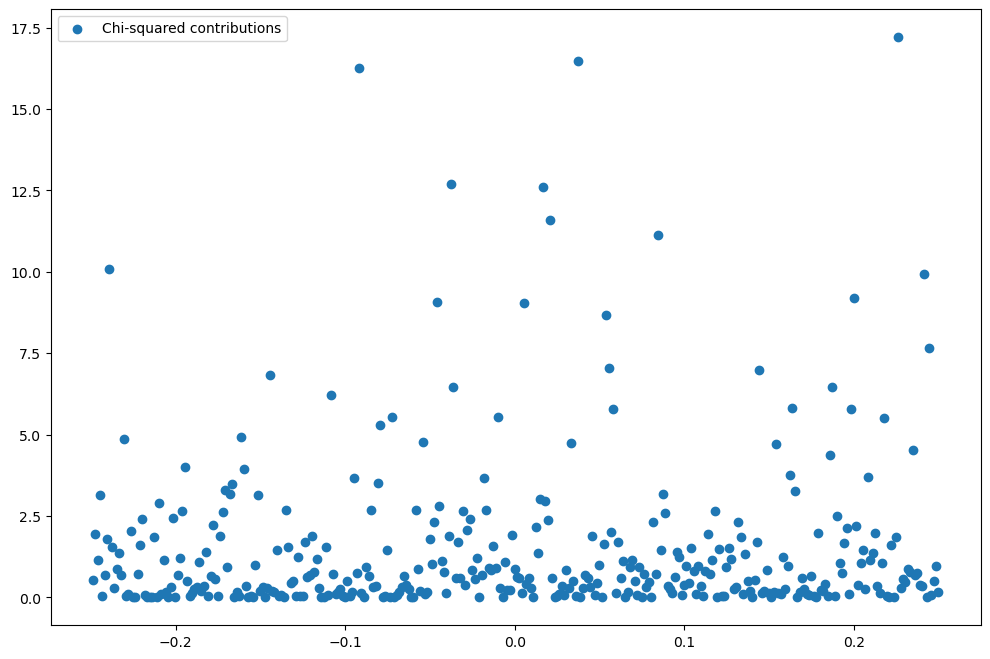

In [19]:
plt.figure(figsize=(12,8))
plt.scatter(
    x_mask,
    chisq_vals,
    label='Chi-squared contributions'
)
plt.legend()

In [20]:
import scipy as sc

In [21]:
import numpy as np
from scipy.stats import chi2

In [22]:
ndof = 100
mean, var, skew, kurt = chi2.stats(ndof, moments='mvsk')

In [23]:
print(mean,var)

100.0 200.0


In [24]:
ndof = 100
print(chi2.ppf(0.99,ndof))

135.80672317102676


In [25]:
print(chi2.ppf(0.997,ndof))

143.22873112148918


In [26]:
# To rescale for so that out-of-transit has reduced chi-squared of 1.0:
#
# Note that chisq = Sum((y_obs - y_calc)/sig_obs)^2)
#
# so if sig_obs^2 is scaled up by S (say), to make reduced chisq=1, then this will apply to
# the in-transit data also. The scaling factor will be chisq_oot/ndof_oot.
# The scaled chisq_int is therefore chisq_int/S.

ndof_int = 157
chi2val_int = 187.15
ndof_oot = 272
chi2val_oot = 349.89
chi2val_scale = chi2val_int/(chi2val_oot/ndof_oot)
print(chi2val_scale)
print(chi2.sf(chi2val_scale,ndof_int))

145.48801051759125
0.7351241495782025
